<a href="https://colab.research.google.com/github/Jay-PhDAI/PhDAI_732_GP1/blob/main/PhDAI732_GP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using snippets of code from https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb
example.

In [80]:
import sys
assert sys.version_info >= (3, 7)

from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
from sklearn.preprocessing import MinMaxScaler

from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import requests # Added requests library

Function to download and import the dataset from my Github.

In [81]:
def load_taxi_data(filename):
    # Define the target path for the final parquet file
    final_parquet_dir = Path("datasets/taxi")
    # The file name as found in the GitHub repository
    source_filename = filename
    final_parquet_path = final_parquet_dir / source_filename

    # Ensure the target directory exists
    final_parquet_dir.mkdir(parents=True, exist_ok=True)

    # If the final parquet file does not exist, proceed with download
    if not final_parquet_path.is_file():

        # Correct URL for raw GitHub content, assuming 'main' branch and correct path within repo
        url = f"https://raw.githubusercontent.com/Jay-PhDAI/PhDAI_732_GP1/main/{source_filename}"

        # Define a temporary path to download the file to first
        temp_download_path = final_parquet_dir / source_filename

        print(f"Downloading data from: {url} using requests library")
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(temp_download_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded to: {temp_download_path}")

        # If the downloaded file needs to be renamed to "taxi.parquet", do it.
        # Assuming the user wants `taxi.parquet` as the final name, regardless of source.
       # if temp_download_path != final_parquet_path:
        #    temp_download_path.rename(final_parquet_path)
        #    print(f"Renamed {temp_download_path.name} to {final_parquet_path.name}")

    else:
        print(f"File already exists: {final_parquet_path}. Skipping download.")

    # Directly read the final parquet file
    return pd.read_parquet(final_parquet_path)

Datasets for NYC green taxicab tripdata now will be downloaded. We are going to use the first 5 months of 2026,(I am only using the first month for testing) and concatenate them into one dataframe.
Then we want to get some info about the dataset. Taking a peek at the dataset:

File already exists: datasets/taxi/green_tripdata_2026-01.parquet. Skipping download.
File already exists: datasets/taxi/green_tripdata_2026-02.parquet. Skipping download.
File already exists: datasets/taxi/green_tripdata_2026-03.parquet. Skipping download.
File already exists: datasets/taxi/green_tripdata_2026-04.parquet. Skipping download.
File already exists: datasets/taxi/green_tripdata_2026-05.parquet. Skipping download.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40272 entries, 0 to 40271
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               40272 non-null  int32         
 1   lpep_pickup_datetime   40272 non-null  datetime64[us]
 2   lpep_dropoff_datetime  40272 non-null  datetime64[us]
 3   store_and_fwd_flag     34858 non-null  object        
 4   RatecodeID             34858 non-null  float64       
 5   PULocationID           40272 non-null  int3

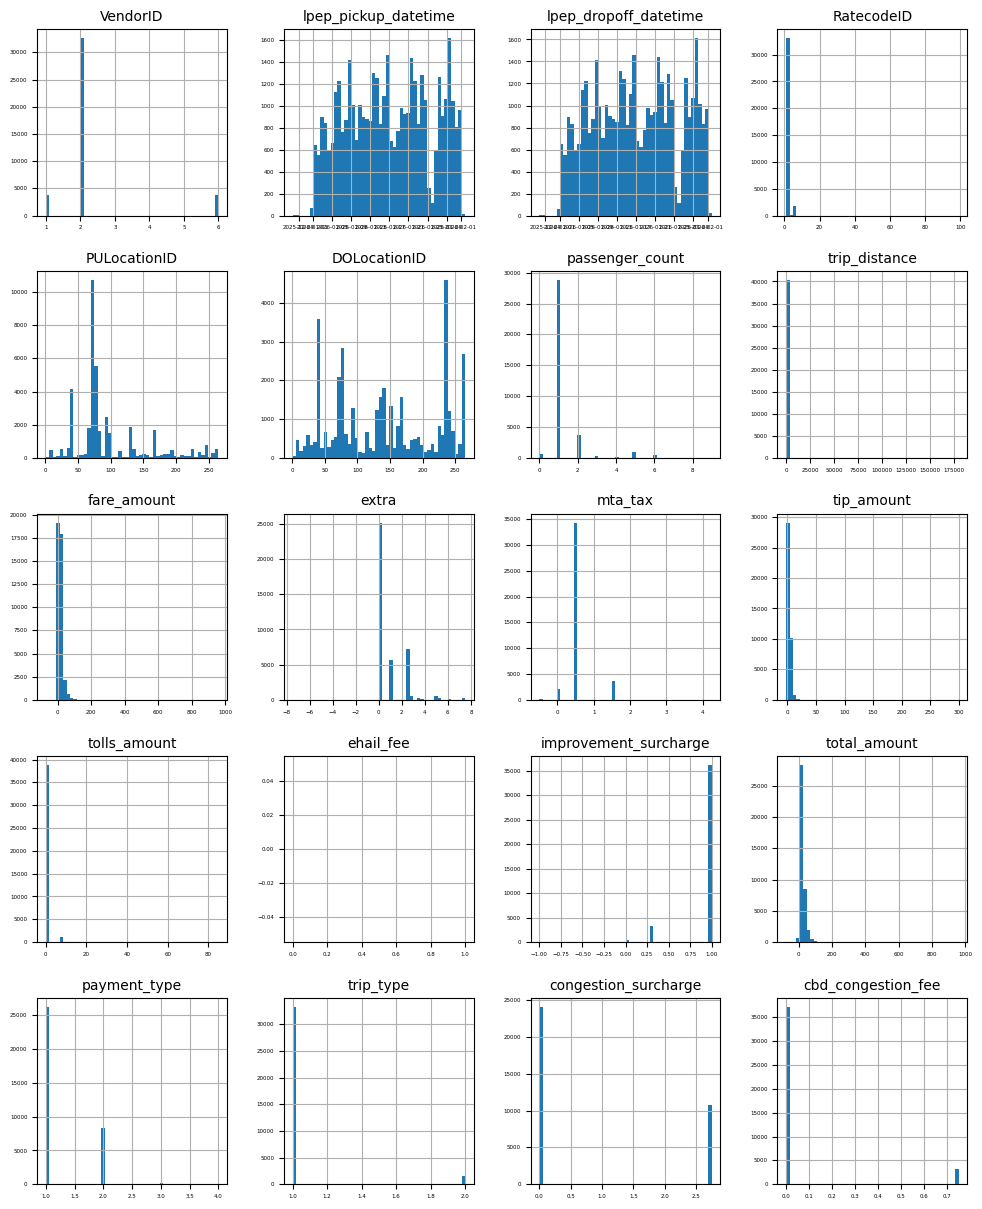

In [82]:
taxi1 = load_taxi_data("green_tripdata_2026-01.parquet")
taxi2 = load_taxi_data("green_tripdata_2026-02.parquet")
taxi3 = load_taxi_data("green_tripdata_2026-03.parquet")
taxi4 = load_taxi_data("green_tripdata_2026-04.parquet")
taxi5 = load_taxi_data("green_tripdata_2026-05.parquet")

#taxi = pd.concat([taxi1, taxi2, taxi3, taxi4, taxi5])
taxi = taxi1
taxi.head()
taxi.info()
taxi.describe()
taxi.store_and_fwd_flag.value_counts()

import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=10)
plt.rc('axes', labelsize=10, titlesize=10)
plt.rc('legend', fontsize=10)
plt.rc('xtick', labelsize=4)
plt.rc('ytick', labelsize=4)

taxi1.hist(bins=50, figsize=(12, 15))
plt.show()

We need some sort of problem to solve. I think it would be interesting to try to determine what time of day is the best for a driver to earn tips.
Maybe make a time series plot of tips vs drop-off time?

scaled_date
0.719130    52
0.709533    51
0.719450    50
0.526871    50
0.885477    49
            ..
0.456174     1
0.116443     1
0.346129     1
0.705374     1
0.705054     1
Name: count, Length: 2574, dtype: int64


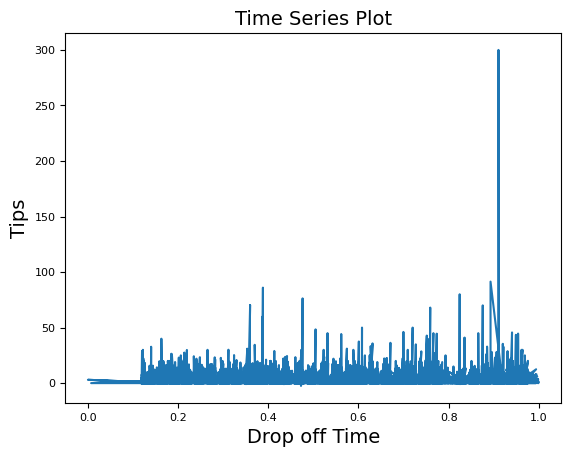

In [91]:
#taxi['lpep_dropoff_datetime'] = pd.to_datetime(taxi['lpep_dropoff_datetime'])
#taxi['month'] = taxi['lpep_dropoff_datetime'].dt.month
#taxi['year'] = taxi['lpep_dropoff_datetime'].dt.year

#scaler = MinMaxScaler()
#taxi[['scaled_month', 'scaled_year']] = scaler.fit_transform(taxi[['month', 'year']])

#print(taxi.month.value_counts())

# 1. Convert to datetime
taxi['lpep_dropoff_datetime'] = pd.to_datetime(taxi['lpep_dropoff_datetime'])

# 2. Convert to Unix timestamp (integer seconds)
taxi['timestamp'] = taxi['lpep_dropoff_datetime'].astype('int64') // 10**9

# 3. Scale the timestamps
from sklearn.preprocessing import MinMaxScaler
taxi[['scaled_date']] = MinMaxScaler().fit_transform(taxi[['timestamp']])

print(taxi.scaled_date.value_counts())

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)


plt.plot(taxi.scaled_date, taxi.tip_amount)
plt.xlabel('Drop off Time')
plt.ylabel('Tips')
plt.title('Time Series Plot')
plt.show()